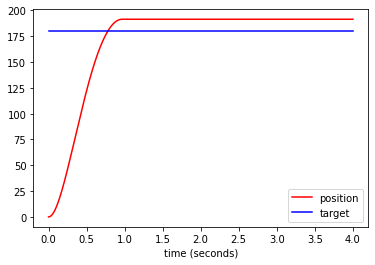

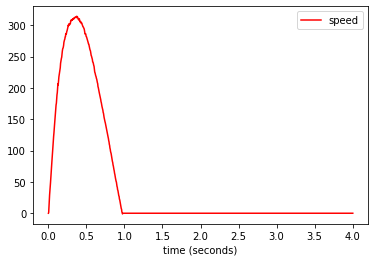

In [5]:
import sys
sys.path.append("../../")

import time
import math

from lib.data.dataplot import *
from lib.utils.time import *
from lib.system.basic import *
from lib.hardware.motor_driver import *

class SimplePositionControl:
    
    def __init__(self, _kp):
        self.kp = _kp
        
    def evaluate(self, delta_t, error):
        return self.kp * error


dpos = DataPlotter()
dpos.set_x("time (seconds)")
dpos.add_y("pos", "position")
dpos.add_y("target", "target")

dvel = DataPlotter()
dvel.set_x("time (seconds)")
dvel.add_y("speed", "speed")

m = MotorDriver()
m.open()

d = Derivator()

target_position = 180.0
ctrl = SimplePositionControl(7.0)

tm = Time()
tm.start()
while tm.get() < 4:

    delta_t = tm.elapsed()
    
    position = m.encoder()
    speed = d.evaluate(delta_t, position)
    
    position = position * 360/84000
    speed = speed * 360/84000
    
    error = target_position - position
    output = ctrl.evaluate(delta_t, error)
    
    if output > 4200:
        output = 4200
    elif output < -4200:
        output = -4200
    
    m.pwm(output) # range [-4200, 4200]

    dpos.append_x(tm.get())
    dpos.append_y("pos", position)
    dpos.append_y("target", target_position)
    
    dvel.append_x(tm.get())
    dvel.append_y("speed", speed)
    
m.pwm(0)
dpos.plot()
dvel.plot()
